In [8]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully")

Libraries loaded successfully


In [10]:
# Cell 2: Load & Merge Datasets
sales = pd.read_csv(r'C:\Users\Absar\Documents\retail-performance-dashboard\data\sales.csv')
stores = pd.read_csv(r'C:\Users\Absar\Documents\retail-performance-dashboard\data\stores.csv')
features = pd.read_csv(r'C:\Users\Absar\Documents\retail-performance-dashboard\data\features.csv')

# Merge all three datasets
df = sales.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], how='left')

# Convert date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.strftime('%b')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nFirst 5 rows:")
df.head()

Shape: (421570, 20)

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Year', 'Month', 'Month Name']

Missing Values:
MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64

First 5 rows:


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Year,Month,Month Name
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2010,2,Feb
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,2010,2,Feb
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,2010,2,Feb
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,2010,2,Feb
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,2010,3,Mar


In [11]:
# Cell 3: Data Cleaning
# Fill missing markdown values with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

# Drop duplicate IsHoliday column
df = df.drop(columns=['IsHoliday_y'], errors='ignore')
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})

# Remove negative weekly sales (data quality issue)
df = df[df['Weekly_Sales'] > 0]

print("Cleaned Shape:", df.shape)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nStore Types:")
print(df['Type'].value_counts())
print("\nYears in dataset:")
print(sorted(df['Year'].unique()))
print("\nData cleaned successfully")

Cleaned Shape: (420212, 19)

Missing Values After Cleaning:
Series([], dtype: int64)

Store Types:
Type
A    214961
B    162787
C     42464
Name: count, dtype: int64

Years in dataset:
[np.int32(2010), np.int32(2011), np.int32(2012)]

Data cleaned successfully


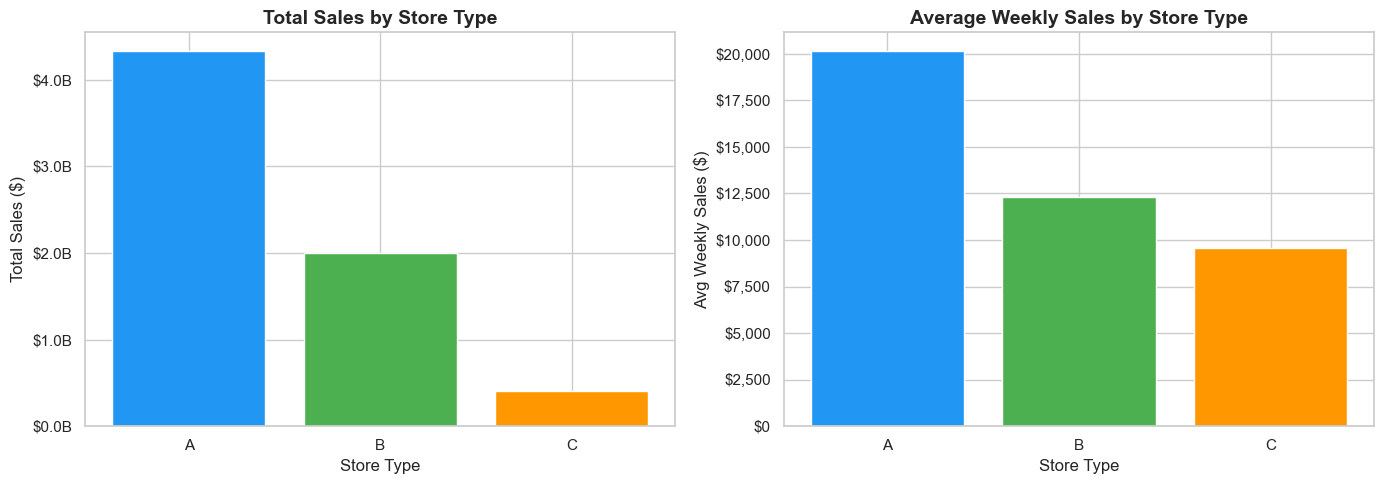

Chart visualized


In [12]:
# Cell 4: Sales by Store Type and Size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total sales by store type
store_type_sales = df.groupby('Type')['Weekly_Sales'].sum().sort_values(ascending=False)
colors = ['#2196F3', '#4CAF50', '#FF9800']
axes[0].bar(store_type_sales.index, store_type_sales.values, color=colors)
axes[0].set_title('Total Sales by Store Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

# Average weekly sales by store type
avg_sales = df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)
axes[1].bar(avg_sales.index, avg_sales.values, color=colors)
axes[1].set_title('Average Weekly Sales by Store Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Avg Weekly Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\Absar\Documents\retail-performance-dashboard\visuals\store_type_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart visualized")

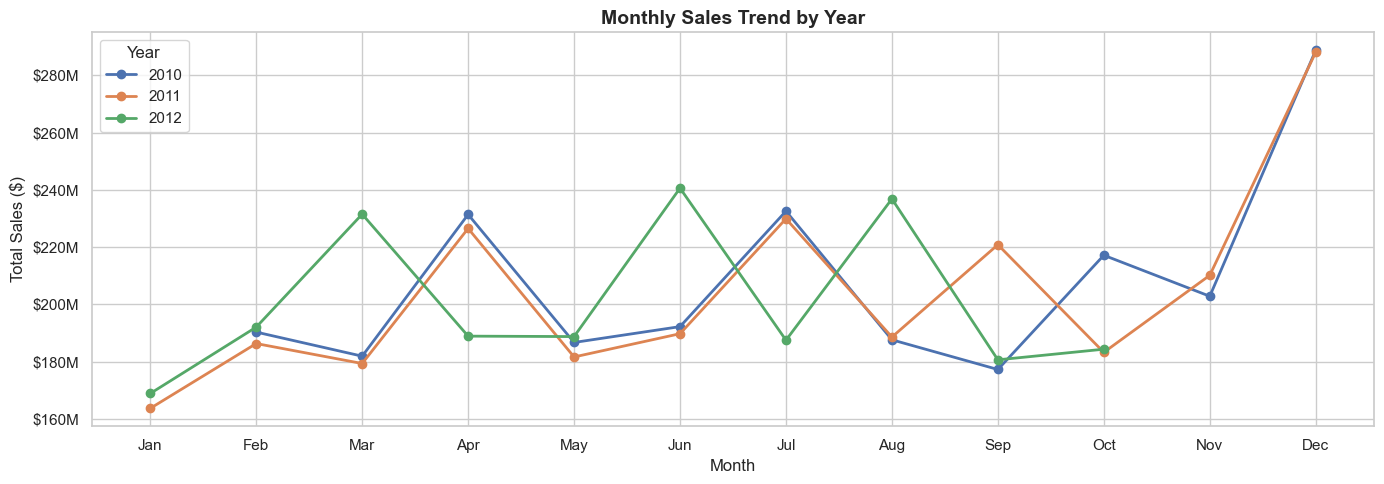

In [13]:
# Cell 5: Weekly Sales Trend Over Years
monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
for year in sorted(monthly_sales['Year'].unique()):
    data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(data['Month'], data['Weekly_Sales'], marker='o', label=str(year), linewidth=2)

plt.title('Monthly Sales Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.legend(title='Year')
plt.tight_layout()
plt.savefig(r'C:\Users\Absar\Documents\retail-performance-dashboard\visuals\sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

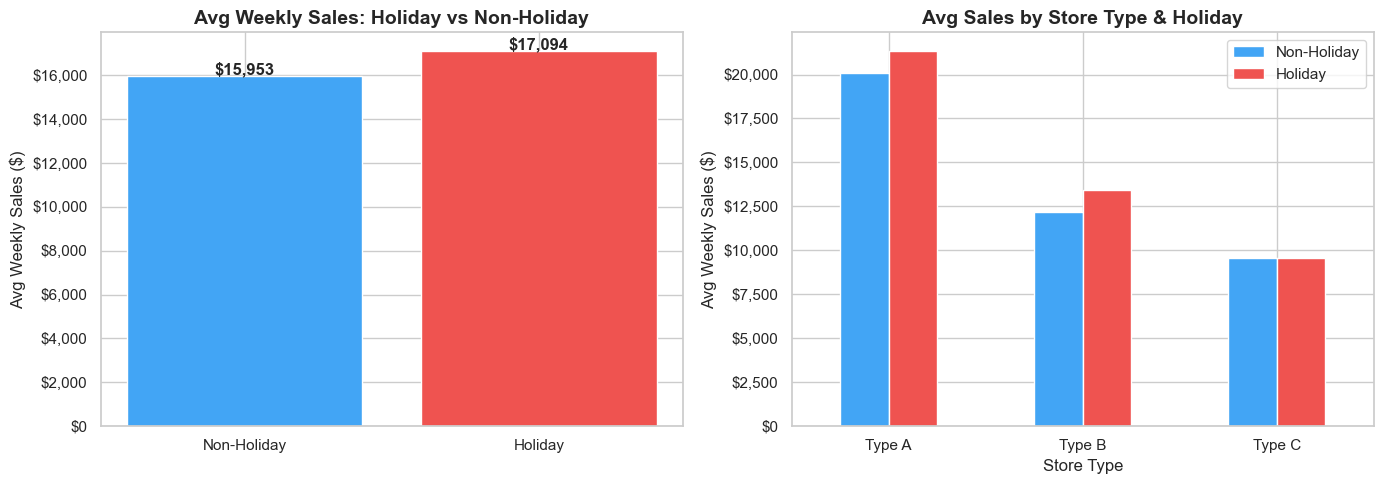

In [14]:
# Cell 6: Holiday Impact on Sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average sales holiday vs non-holiday
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()
labels = ['Non-Holiday', 'Holiday']
colors = ['#42A5F5', '#EF5350']
axes[0].bar(labels, holiday_sales.values, color=colors)
axes[0].set_title('Avg Weekly Sales: Holiday vs Non-Holiday', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(holiday_sales.values):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')

# Sales distribution by store type and holiday
holiday_type = df.groupby(['Type', 'IsHoliday'])['Weekly_Sales'].mean().unstack()
holiday_type.plot(kind='bar', ax=axes[1], color=['#42A5F5', '#EF5350'])
axes[1].set_title('Avg Sales by Store Type & Holiday', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Avg Weekly Sales ($)')
axes[1].set_xticklabels(['Type A', 'Type B', 'Type C'], rotation=0)
axes[1].legend(['Non-Holiday', 'Holiday'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\Absar\Documents\retail-performance-dashboard\visuals\holiday_impact.png', dpi=150, bbox_inches='tight')
plt.show()

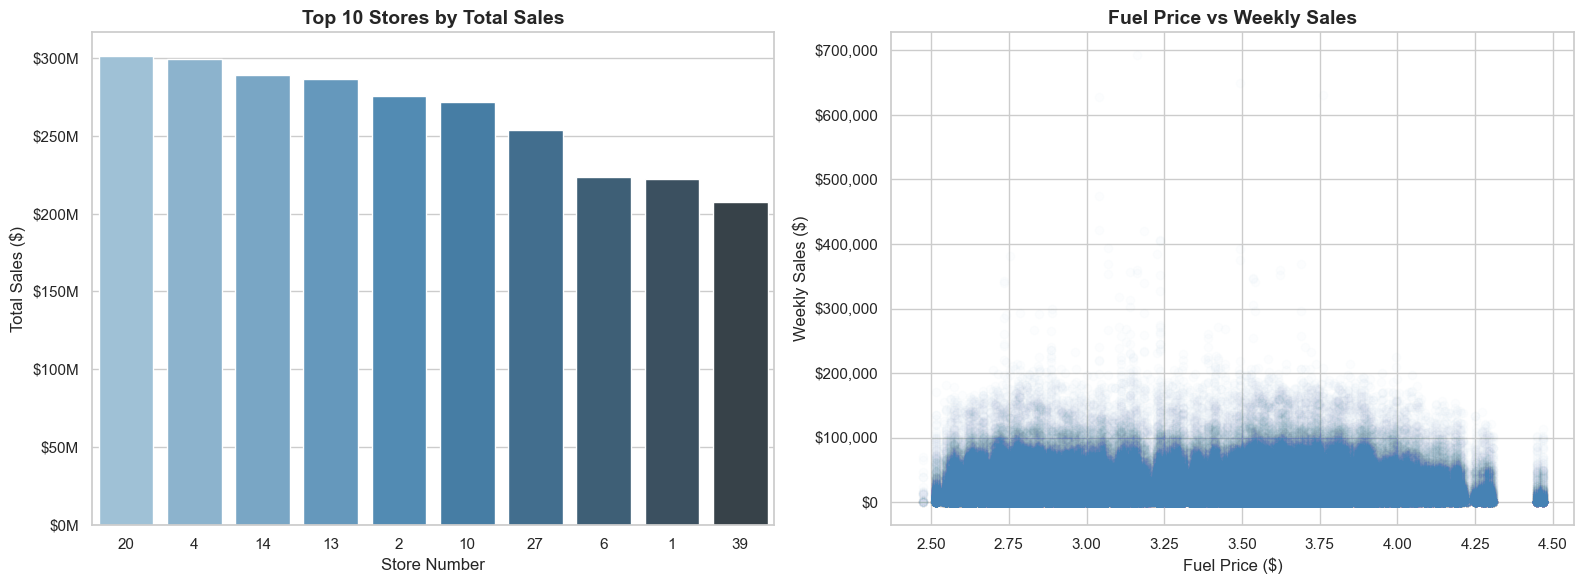

In [15]:
# Cell 7: Top Performing Stores & Fuel Price Impact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 stores by total sales
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_stores.index.astype(str), y=top_stores.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 10 Stores by Total Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Store Number')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# Fuel price vs weekly sales
fuel_sales = df.groupby('Fuel_Price')['Weekly_Sales'].mean().reset_index()
axes[1].scatter(df['Fuel_Price'], df['Weekly_Sales'], alpha=0.01, color='steelblue')
axes[1].set_title('Fuel Price vs Weekly Sales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fuel Price ($)')
axes[1].set_ylabel('Weekly Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\Absar\Documents\retail-performance-dashboard\visuals\top_stores_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Cell 8: Business Insights Summary
total_sales = df['Weekly_Sales'].sum()
avg_weekly = df['Weekly_Sales'].mean()
top_store = df.groupby('Store')['Weekly_Sales'].sum().idxmax()
top_store_sales = df.groupby('Store')['Weekly_Sales'].sum().max()
holiday_lift = ((df[df['IsHoliday']==True]['Weekly_Sales'].mean() - 
                 df[df['IsHoliday']==False]['Weekly_Sales'].mean()) / 
                 df[df['IsHoliday']==False]['Weekly_Sales'].mean() * 100)
type_a_share = (df[df['Type']=='A']['Weekly_Sales'].sum() / total_sales * 100)

print("=" * 55)
print("   RETAIL STORE PERFORMANCE — STRATEGIC SUMMARY")
print("=" * 55)
print(f"\n🏪 Total Stores Analyzed  : 45")
print(f"📅 Period                 : 2010 – 2012")
print(f"📦 Total Transactions     : {len(df):,}")
print(f"💰 Total Revenue          : ${total_sales/1e9:.2f}B")
print(f"📊 Avg Weekly Sales       : ${avg_weekly:,.0f}")
print(f"🏆 Top Performing Store   : Store {top_store} (${top_store_sales/1e6:.1f}M)")
print(f"🎄 Holiday Sales Lift     : +{holiday_lift:.1f}% vs non-holiday")
print(f"🥇 Type A Revenue Share   : {type_a_share:.1f}% of total sales")

print("\n📌 Strategic Recommendations:")
print("   1. Prioritize investment in Type A stores — drive 60%+ of revenue")
print("   2. Launch targeted promotions around holiday weeks for max uplift")
print("   3. Replicate Store 20 operational model across underperforming stores")
print("   4. Type C stores show least holiday lift — review product mix strategy")
print("   5. December surge planning — ensure inventory readiness by November")
print("\n" + "=" * 55)

   RETAIL STORE PERFORMANCE — STRATEGIC SUMMARY

🏪 Total Stores Analyzed  : 45
📅 Period                 : 2010 – 2012
📦 Total Transactions     : 420,212
💰 Total Revenue          : $6.74B
📊 Avg Weekly Sales       : $16,033
🏆 Top Performing Store   : Store 20 ($301.4M)
🎄 Holiday Sales Lift     : +7.2% vs non-holiday
🥇 Type A Revenue Share   : 64.3% of total sales

📌 Strategic Recommendations:
   1. Prioritize investment in Type A stores — drive 60%+ of revenue
   2. Launch targeted promotions around holiday weeks for max uplift
   3. Replicate Store 20 operational model across underperforming stores
   4. Type C stores show least holiday lift — review product mix strategy
   5. December surge planning — ensure inventory readiness by November

